In [1]:
import pandas as pd
import matplotlib.ticker as mticker
import numpy as np
import networkx as nx
import matplotlib.patches as mpatches
import dowhy
from IPython.display import Image

/home/yash/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [120]:
pip install psmpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [148]:
plt.rcParams.update(mpl.rcParamsDefault)

In [151]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    # Figure
    "figure.figsize"        : (7, 4),
    "figure.dpi"            : 100,
    "savefig.dpi"           : 300,

    # Font
    "font.family"           : "serif",
    "font.size"             : 12,
    "text.usetex"           : True,

    # Axes
    "axes.titlesize"        : 14,
    "axes.titleweight"      : "bold",
    "axes.labelsize"        : 13,
    "axes.labelpad"         : 10,
    "axes.spines.top"       : False,
    "axes.spines.right"     : False,
    "axes.grid"             : False,
    "grid.alpha"            : 0.4,

    # Ticks
    "xtick.labelsize"       : 10,
    "ytick.labelsize"       : 10,

    # Legend
    "legend.fontsize"       : 11,
    "legend.framealpha"     : 0.7,

    # Saving
    "savefig.bbox"          : "tight",
})

# Part 0: Data Familiarisation 

In [76]:
data = pd.read_csv("data_dengue_net_v2.csv", index_col = [0])
data["income"] = data["income"] * 10 # Scaling the Income colums to convert it into Rupees
sample_size = data.shape[0]

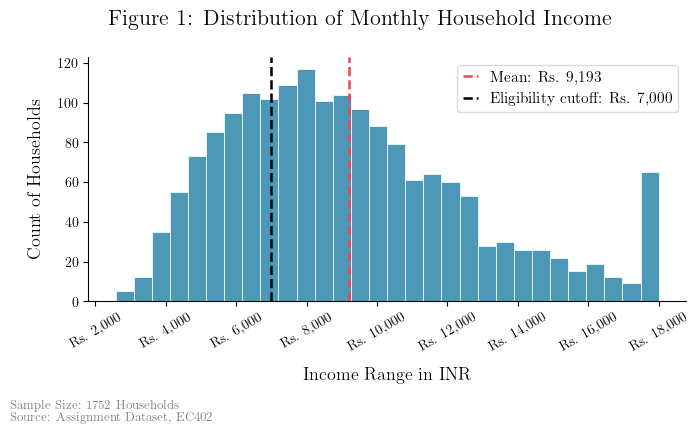

In [159]:
fig, ax = plt.subplots()  # ← remove figsize here, let rcParams handle it
ax.hist(data["income"], density=False, bins=30, color='#2E86AB', edgecolor='white', linewidth=0.6, alpha=0.85)
ax.set_ylabel("Count of Households", fontsize=13, labelpad=10)
ax.set_xlabel("Income Range in INR", fontsize=13, labelpad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rs. {x:,.0f}"))
ax.tick_params(axis='x', rotation=30)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
mean_val = data["income"].mean()
eligibility = 7000
ax.axvline(mean_val,    color="#E84855", linestyle="--", linewidth=1.8, label=f"Mean: Rs. {mean_val:,.0f}")
ax.axvline(eligibility, color="black",   linestyle="--", linewidth=1.8, label=f"Eligibility cutoff: Rs. {eligibility:,.0f}")
ax.legend(fontsize=11, handlelength=1)
fig.suptitle("Figure 1: Distribution of Monthly Household Income", fontsize=16, fontweight="bold", x=0.5, ha="center")
fig.text(0, -0.02, "Sample Size: 1752 Households", fontsize=9, color="gray", ha='left')
fig.text(0, -0.05, "Source: Assignment Dataset, EC402", fontsize=9, color="gray", ha='left')
plt.tight_layout()
plt.savefig("Figure_!.png")
plt.show()

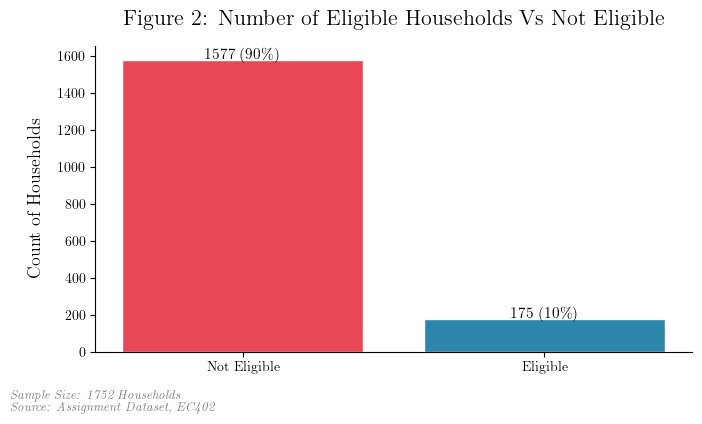

In [160]:
#Constructing the eligible variable
data["is_eligible"] = np.where( (data['income'] < 7000) & (data['household'] > 4), 1, 0)
counts = data["is_eligible"].value_counts().sort_index()
fig, ax = plt.subplots()
ax.bar(["Not Eligible", "Eligible"], counts, color=["#E84855", "#2E86AB"], edgecolor="white")
ax.set_ylabel("Count of Households")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.title("Figure 2: Number of Eligible Households Vs Not Eligible", fontweight="bold", fontsize=16, pad=15)
for i, val in enumerate(counts):
    ax.text(i, val + 10, f"{val} ({(val/sample_size)*100:.0f}\%)", ha="center", fontsize=11)
fig.text(0, -0.02, r"""\textit{Sample Size: 1752 Households}""", fontsize=9, color="gray", ha='left')
fig.text(0, -0.05, r"""\textit{Source: Assignment Dataset, EC402}""", fontsize=9, color="gray", ha='left')
plt.tight_layout()
plt.show()

In [101]:
#Comparing Mosquito Net Users Vs Not Users
data["is_netUser"] = np.where(data["net_num"] > 0, 1, 0)

variables = ["income", "dengue_risk", "household" , "health", 'temperature', 'resistance', 'rainfall']
summary_stats = {}

for var in variables:
    summary_stats[var] = data.groupby("is_netUser")[var].agg(
        count="count",
        mean="mean",
        std="std",
        min="min",
        max="max"
    )

summary_df = pd.concat(summary_stats, axis=0)
summary_df.index.names = ["variable", "is_netUser"]
summary_df.style.format("{:.2f}").set_caption("Summary Statistics by Internet Usage")

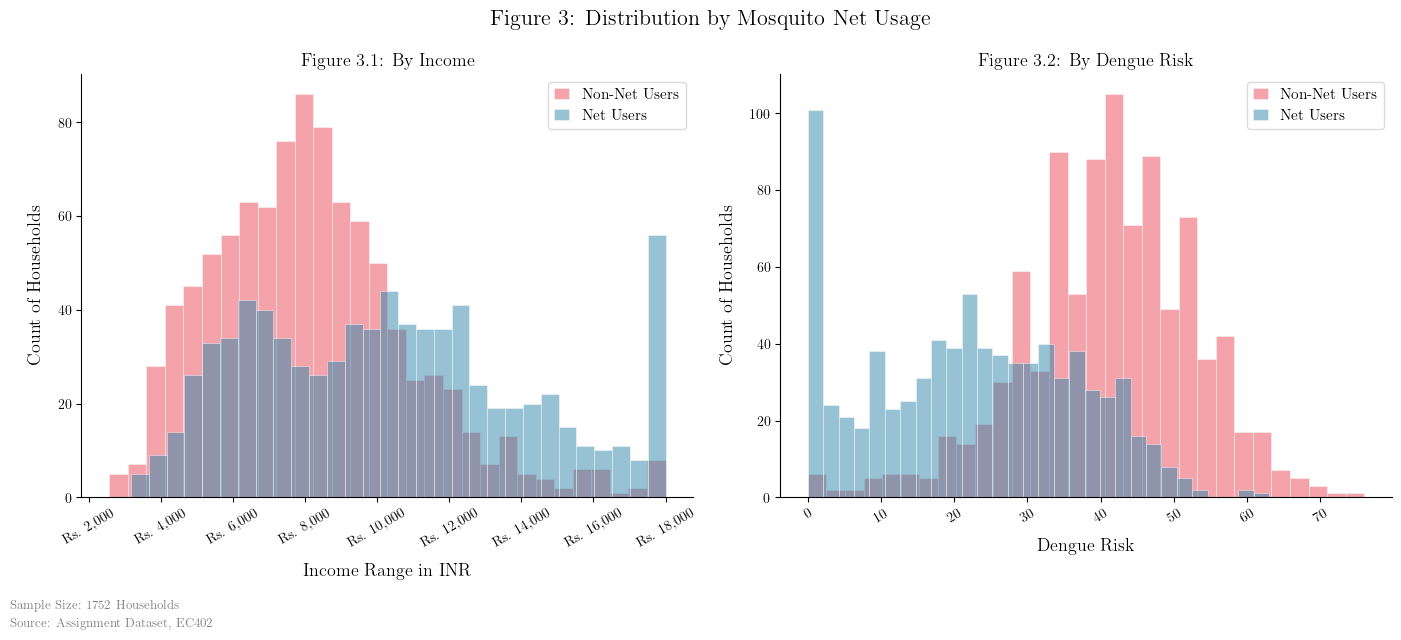

In [161]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Income
ax1.hist(data[data["is_netUser"] == 0]["income"], bins=30, color="#E84855", edgecolor="white",
        linewidth=0.6, alpha=0.5, label="Non-Net Users")
ax1.hist(data[data["is_netUser"] == 1]["income"], bins=30, color="#2E86AB", edgecolor="white",
        linewidth=0.6, alpha=0.5, label="Net Users")
ax1.set_ylabel("Count of Households", fontsize=13, labelpad=10)
ax1.set_xlabel("Income Range in INR", fontsize=13, labelpad=10)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rs. {x:,.0f}"))
ax1.tick_params(axis='x', rotation=30)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.legend(fontsize=11, handlelength=1)
ax1.set_title("Figure 3.1: By Income", fontweight="bold", fontsize=13)

# Dengue Risk
ax2.hist(data[data["is_netUser"] == 0]["dengue_risk"], bins=30, color="#E84855", edgecolor="white",
        linewidth=0.6, alpha=0.5, label="Non-Net Users")
ax2.hist(data[data["is_netUser"] == 1]["dengue_risk"], bins=30, color="#2E86AB", edgecolor="white",
        linewidth=0.6, alpha=0.5, label="Net Users")
ax2.set_ylabel("Count of Households", fontsize=13, labelpad=10)
ax2.set_xlabel("Dengue Risk", fontsize=13, labelpad=10)
ax2.tick_params(axis='x', rotation=30)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.legend(fontsize=11, handlelength=1)
ax2.set_title("Figure 3.2: By Dengue Risk", fontweight="bold", fontsize=13)

fig.suptitle("Figure 3: Distribution by Mosquito Net Usage", fontweight="bold", fontsize=16, x=0.5, ha = "center")
fig.text(0, -0.02, "Sample Size: 1752 Households", fontsize=9, color="gray", ha='left')
fig.text(0, -0.05, "Source: Assignment Dataset, EC402", fontsize=9, color="gray", ha='left')

plt.tight_layout()
plt.show()

# Part 1: Causal Framework

$\underline{\text{Research Question:}}$ $\text{What is the causal impact of using mosquito net on contracting dengue fever?}$ 

The figure below suggests that households (those who use the nets) only own multiple (>1) mosquito net if the Household size too big to accomodate all the members within a single Net. Hence, it is reasonable to assume that among those who use nets, none of them are "cramped up" in a single net reducing it's effectiveness, therefore we may define the treatment as a Binary variable indicating whether a Household uses a net or not (i.e. has more than or equal to one net).   

/tmp/ipykernel_52165/853261327.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(plot_data, labels=household_groups, patch_artist=True,


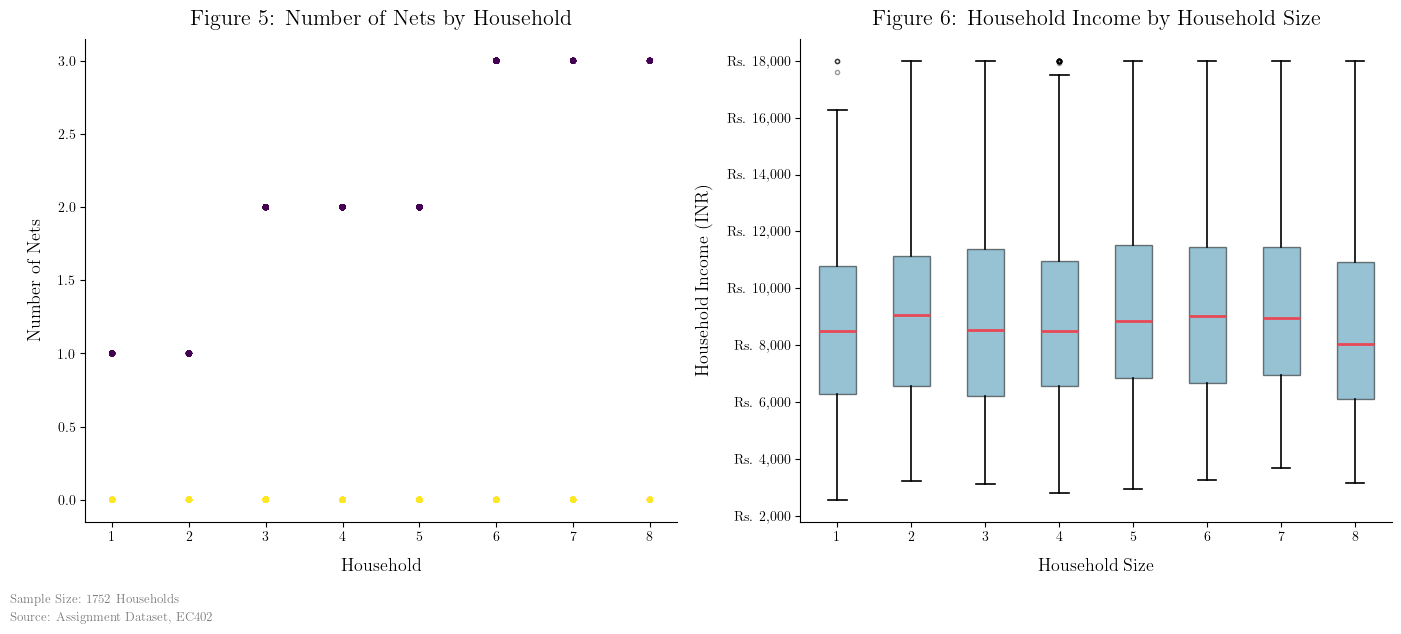

In [152]:
fig, ax = plt.subplots(nrows=1,ncols=2, figsize = (14,6))

col = np.where((data["net_num"] == 0), 1, 0)
ax[0].scatter(data["household"], data["net_num"], c = col, alpha=0.4, s=20, edgecolors="none")
ax[0].set_xlabel("Household", fontsize=13, labelpad=10)
ax[0].set_ylabel("Number of Nets", fontsize=13, labelpad=10)
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)
ax[0].set_title("Figure 5: Number of Nets by Household", fontweight="bold", fontsize=16, pad = 10)
#fig.suptitle("Figure 5: Number of Nets by Household", fontweight="bold", fontsize=16, x=0.5, ha="center")

household_groups = sorted(data["household"].unique())
plot_data = [data[data["household"] == h]["income"].values for h in household_groups]

ax[1].boxplot(plot_data, labels=household_groups, patch_artist=True,
              boxprops=dict(facecolor="#2E86AB", alpha=0.5),
              medianprops=dict(color="#E84855", linewidth=2),
              whiskerprops=dict(linewidth=1.2),
              capprops=dict(linewidth=1.2),
              flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax[1].set_xlabel("Household Size", fontsize=13, labelpad=10)
ax[1].set_ylabel("Household Income (INR)", fontsize=13, labelpad=10)
ax[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rs. {x:,.0f}"))
ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)
ax[1].set_title("Figure 6: Household Income by Household Size", fontweight="bold", fontsize=16, pad=10)

fig.text(0, -0.02, "Sample Size: 1752 Households", fontsize=9, color="gray", ha='left')
fig.text(0, -0.05, "Source: Assignment Dataset, EC402", fontsize=9, color="gray", ha='left')
plt.tight_layout()
plt.show()

- Figure 5 indicates that among the househols which use at least one mosquito net (blue dots), the number of persons inside a net is always one or two, irrespective of the household size. Therefore, we might as well treat **net** as the treatment insteaad of net_num.
- We hypothesise that **household** doesn't causally affect **dengue_risk** and provie heuristic argument to support the hypothesis. One might argue, against the hypothesis that bigger households might live in denser and relatively unhygenic areas (compared to smaller households) and therefore might be at a higher risk of contracting dengue. This therfore should imply, that taking monthly income as a proxy for living conditons, a negetive correlation between household size and income. Figure 6 reveals no such correlation, supporting our hypothesis.

___

- The research question can be stated as: Does using a mosquito net causally reduce a household's risk of contracting dengue fever? In this context, it is more useful to calculate <b>ATE</b> as it tells us the effect of using a net versus not using a net **across the entire population**. If the ATE is negetive then we can generalise and say that using net reduces the risk of contracting the dengue fever. On the other hand, ATE tells us what the risk of contracting the dengue fever would have been had the individuals who used the net, not used it. Given the research question, the former is more meaningful as it pertains to the entire population and not just a part of it which takes the treatment (uses the net). 

- In fact, if we want to provide evidence in favour of using mosquito net to convince those individuals who don't use it, it is more appropriate to estimate the ATU, as it would tell us what how the people not taking the treatment (not using the net) would benefit (in terms of risk of contracting the dengue fever) had they used the net. 

- Since, a priori we have no reason to believe homogenous treatment effects, the choice of estimand matters. Under the assumption of homogenous treatment effect, the estimates of ATE, ATU and ATT are all expected to be the same and hence the choice of estimand wouldn't have mattered.  

- For Regression and matching analysis **net** variable should be used as the treatment variable.

## Creating the DAG

In [217]:
graph_v1 = [
        ("is_netUser", "dengue_risk"),
        ("income", "is_netUser"),
        ("health", "dengue_risk"),
        ("income", "health"),
        ("income", "is_eligible"),
        ("household", "is_eligible"),
        ("household", "is_netUser"),
        ("household", "income"),
        ("temperature", "health"),
        ("temperature", "dengue_risk"),
        ("temperature", "income"),
        ("rainfall", "temperature"),
        ("rainfall", "dengue_risk"),
        #("rainfall", "is_netUser"),
        ("resistance", "dengue_risk"),
        #("resistance", "is_netUser"),
        ("is_eligible", "is_netUser"),
    ]

graph_v2 = [
        ("is_eligible", "is_netUser"),
        ("is_netUser", "dengue_risk"),
        ("income", "is_netUser"),
        ("health", "dengue_risk"),
        ("health", "income"),
        ("income", "is_eligible"),
        ("household", "is_eligible"),
        ("household", "is_netUser"),
        ("household", "income"),
        #("temperature", "health"),
        ("temperature", "dengue_risk"),
        #("temperature", "income"),
        ("rainfall", "temperature"),
        ("rainfall", "dengue_risk"),
        #("rainfall", "is_netUser"),
        ("resistance", "dengue_risk"),
        #("resistance", "is_netUser"),
    ]

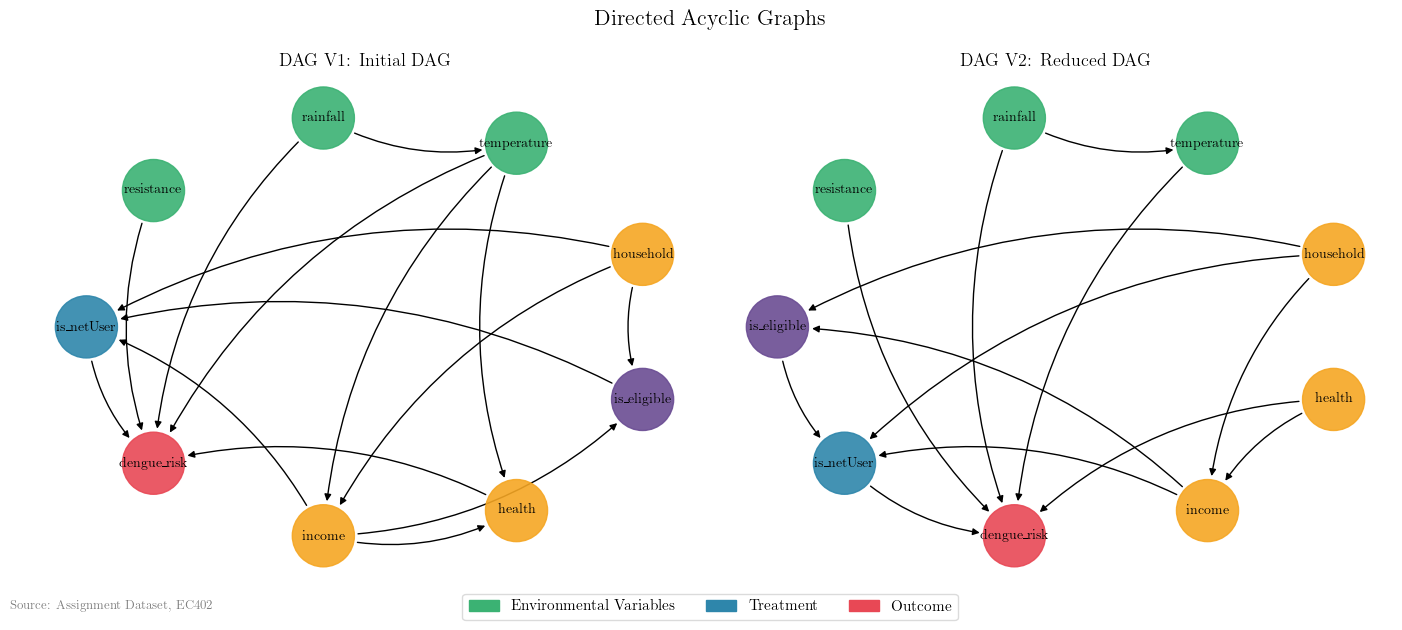

In [218]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6)) 

# --- DAG 1 ---
G_v1 = nx.DiGraph()
G_v1.add_edges_from(graph_v1)
pos_v1 = nx.shell_layout(G_v1)
nx.draw_networkx_nodes(G_v1, pos_v1, node_color=[node_colors[n] for n in G_v1.nodes()], node_size=2000, alpha=0.9, ax=ax1)
nx.draw_networkx_labels(G_v1, pos_v1, font_color="black", font_size=10, font_weight="bold", ax=ax1)
nx.draw_networkx_edges(G_v1, pos_v1, edge_color="black", arrows=True,
                       arrowstyle="-|>", arrowsize=10,
                       connectionstyle="arc3,rad=0.2", ax=ax1, min_target_margin=25, min_source_margin=25)
ax1.set_title("DAG V1: Initial DAG", fontweight="bold", fontsize=13)
ax1.axis("off")

# --- DAG 2 ---
G_v2 = nx.DiGraph()
G_v2.add_edges_from(graph_v2)
pos_v2 = nx.shell_layout(G_v2)
nx.draw_networkx_nodes(G_v2, pos_v2, node_color=[node_colors[n] for n in G_v2.nodes()], node_size=2000, alpha=0.9, ax=ax2)
nx.draw_networkx_labels(G_v2, pos_v2, font_color="black", font_size=10, font_weight="bold", ax=ax2)
nx.draw_networkx_edges(G_v2, pos_v2, edge_color="black", arrows=True,
                       arrowstyle="-|>", arrowsize=10,
                       connectionstyle="arc3,rad=0.2", ax=ax2, min_target_margin=25, min_source_margin=25)
ax2.set_title("DAG V2: Reduced DAG", fontweight="bold", fontsize=13)
ax2.axis("off")

# --- Legend in bottom right ---
legend_elements = [
    mpatches.Patch(color="#3BB273", label="Environmental Variables"),
    mpatches.Patch(color="#2E86AB", label="Treatment"),
    mpatches.Patch(color="#E84855", label="Outcome"),
]
fig.legend(handles=legend_elements, fontsize=11, framealpha=0.7,
           loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.05))

fig.suptitle("Directed Acyclic Graphs", fontweight="bold", fontsize=16)
fig.text(0, -0.02, "Source: Assignment Dataset, EC402", fontsize=9, color="gray", ha='left')
plt.tight_layout()
plt.show()

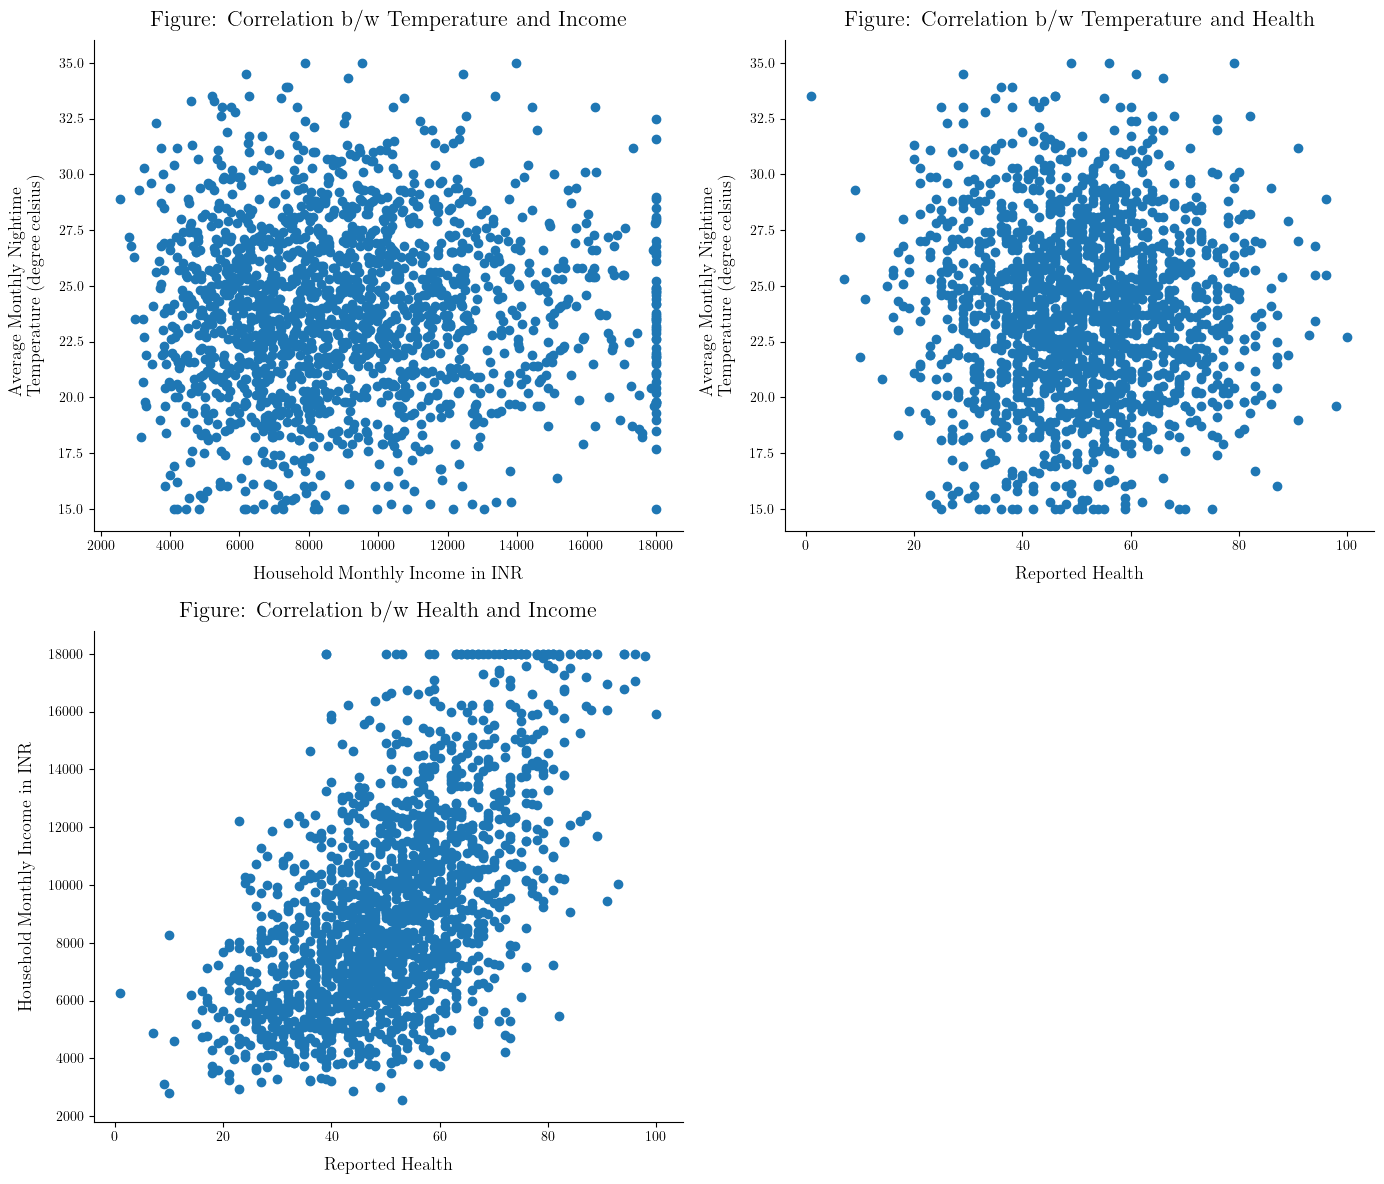

In [219]:
fig,ax = plt.subplots(2,2, figsize = (14,12))
ax[0, 0].scatter(y = data["temperature"], x = data["income"]) # rules out correlation between temp and income 
ax[0, 0].set_ylabel(r"""\noindent Average Monthly Nightime \newline Temperature (degree celsius)""", fontsize=13)
ax[0, 0].set_xlabel("Household Monthly Income in INR", fontsize=13)
ax[0, 0].set_title(r'Figure: Correlation b/w Temperature and Income', fontweight="bold", fontsize=16, pad=10)

ax[0, 1].scatter(x = data["health"], y = data["temperature"]) # rules out correlation between temp and health 
ax[0, 1].set_xlabel(r"Reported Health", fontsize=13)
ax[0, 1].set_ylabel(r"\noindent Average Monthly Nightime \newline Temperature (degree celsius)", fontsize=13)
ax[0, 1].set_title(r"Figure: Correlation b/w Temperature and Health", fontweight="bold", fontsize=16, pad=10)

ax[1, 0].scatter(y = data["income"], x = data["health"]) # provides heuristic evidence of correlation between Health and Income
ax[1, 0].set_ylabel("Household Monthly Income in INR", fontsize=13)
ax[1, 0].set_xlabel("Reported Health", fontsize=13)
ax[1, 0].set_title("Figure: Correlation b/w Health and Income", fontweight="bold", fontsize = 16, pad=10)

ax[1, 1].set_axis_off()

plt.tight_layout() 
plt.show()

## Minimum Sufficient Adjustment Set

In [222]:
from pgmpy.base import DAG
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference.CausalInference import CausalInference

model_1 = DiscreteBayesianNetwork(graph_v1)
model_2 = DiscreteBayesianNetwork(graph_v2)

causal_1 = CausalInference(model_1)
causal_2 = CausalInference(model_2)

adjustment_set_1 = causal_1.get_minimal_adjustment_set(
    X="is_netUser",      # treatment
    Y="dengue_risk"      # outcome
)

adjustment_set_2 = causal_2.get_minimal_adjustment_set(
    X="is_netUser",      # treatment
    Y="dengue_risk"      # outcome
)



print("Minimum Sufficient Adjustment Set for DAG version 1:", adjustment_set_1)
print("Minimum Sufficient Adjustment Set for reduced DAG:", adjustment_set_2)

Minimum Sufficient Adjustment Set for DAG version 1: {'temperature', 'income'}
Minimum Sufficient Adjustment Set for reduced DAG: {'income', 'household'}


## Back door Paths (Appendix)

In [221]:
from cgm import CausalGraphicalModel

cgm = CausalGraphicalModel(
    nodes=["is_netUser", "dengue_risk", "income", "health", "is_eligible", 
           "household", "temperature", "rainfall", "resistance"],
    edges=graph_v1
)

# all backdoor paths
backdoor_paths = cgm.get_all_backdoor_paths(x="is_netUser", y="dengue_risk")
print("Backdoor Paths:")
for i, path in enumerate(backdoor_paths, 1):
    # Check actual edge direction for each step in the path
    path_str = []
    for a, b in zip(path[:-1], path[1:]):
        if cgm.dag.has_edge(a, b):
            path_str.append(f"{a} → {b}")
        else:
            path_str.append(f"{a} ← {b}")
    print(f"  {i}. {' | '.join(path_str)}")

# all valid backdoor adjustment sets
adjustment_sets = cgm.get_all_backdoor_adjustment_sets(x="is_netUser", y="dengue_risk")
print("\nValid Backdoor Adjustment Sets:")
for i, s in enumerate(adjustment_sets, 1):
    print(f"  {i}. {set(s)}")


Backdoor Paths:
  1. is_netUser ← income | income → health | health → dengue_risk
  2. is_netUser ← income | income → health | health ← temperature | temperature → dengue_risk
  3. is_netUser ← income | income → health | health ← temperature | temperature ← rainfall | rainfall → dengue_risk
  4. is_netUser ← income | income ← temperature | temperature → health | health → dengue_risk
  5. is_netUser ← income | income ← temperature | temperature → dengue_risk
  6. is_netUser ← income | income ← temperature | temperature ← rainfall | rainfall → dengue_risk
  7. is_netUser ← is_eligible | is_eligible ← income | income → health | health → dengue_risk
  8. is_netUser ← is_eligible | is_eligible ← income | income → health | health ← temperature | temperature → dengue_risk
  9. is_netUser ← is_eligible | is_eligible ← income | income → health | health ← temperature | temperature ← rainfall | rainfall → dengue_risk
  10. is_netUser ← is_eligible | is_eligible ← income | income ← temperature | t

# Reference
1. **All Backdoor Paths:** https://github.com/ijmbarr/causalgraphicalmodels/blob/master/causalgraphicalmodels/cgm.py